# Notebook 01 — Data Loading, Cleaning & Exploratory Data Analysis

**Project:** Multivariate Weather Forecasting with Attention  
**Dataset:** Jena Climate Dataset (Max Planck Institute, 2009–2016)

This notebook covers:
1. Loading and auditing the raw 10-minute Jena Climate dataset
2. Cleaning sensor anomalies (faulty wind velocity readings)
3. Resampling from 10-minute to hourly resolution
4. Generating all 5 EDA visualisations


## 0. Environment Setup & Imports

In [1]:
import sys
import os

# Ensure the project root is on the path so `src` is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

from src.config import (
    RAW_DATA_PATH, CLEANED_DATA_PATH, TARGET_COLS,
    PHYSICAL_BOUNDS, FIGURES_DIR
)
print("✅ Imports successful. Project root:", PROJECT_ROOT)


✅ Imports successful. Project root: D:\AIML\Multivariate Weather Forecasting with Attention


## 1. Load Raw Dataset

In [2]:
from src.data_loader import load_raw_data, audit_dataset

# Load raw 10-minute dataset
raw_df = load_raw_data(RAW_DATA_PATH)
print(f"\nRaw dataset shape: {raw_df.shape}")
print(f"Date range: {raw_df.index[0]}  →  {raw_df.index[-1]}")
raw_df.head()


[*] Loading raw dataset from: D:\AIML\Multivariate Weather Forecasting with Attention\Dataset\jena_climate_2009_2016.csv


[+] Loaded 420,551 rows with 15 columns.
[*] Parsing 'Date Time' column...



Raw dataset shape: (420551, 14)
Date range: 2009-01-01 00:10:00  →  2017-01-01 00:00:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 2. Dataset Integrity Audit

In [3]:
audit_results = audit_dataset(raw_df)
print("\nAudit Summary:")
for k, v in audit_results.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")



--- DATASET INTEGRITY AUDIT ---
[-] Duplicate timestamps: 327
[-] Total missing cells in raw data: 0
[-] Faulty wind speed readings (wv < 0 m/s): 18
[-] Faulty max wind speed readings (max. wv < 0 m/s): 20

--- Summary of Target Variables (Raw) ---
    T (degC)     | Min:   -23.01 | Max:    37.28 | Mean:     9.45
    p (mbar)     | Min:   913.60 | Max:  1015.35 | Mean:   989.21
    rh (%)       | Min:    12.95 | Max:   100.00 | Mean:    76.01
    wv (m/s)     | Min: -9999.00 | Max:    28.49 | Mean:     1.70

Audit Summary:
  duplicate_timestamps: 327
  faulty_wv_count: 18
  faulty_max_wv_count: 20


### 2.1 Inspect Target Variable Statistics (Raw)

In [4]:
print("Target Variable Descriptive Statistics (Raw Data):")
raw_df[TARGET_COLS].describe().round(3)


Target Variable Descriptive Statistics (Raw Data):


,T (degC),p (mbar),rh (%),wv (m/s)
count,420551.000,420551.000,420551.000,420551.000
mean,9.450,989.213,76.008,1.702
std,8.423,8.358,16.476,65.447
min,-23.010,913.600,12.950,-9999.000
25%,3.360,984.200,65.210,0.990
50%,9.420,989.580,79.300,1.760
75%,15.470,994.720,89.400,2.860
max,37.280,1015.350,100.000,28.490


## 3. Clean & Resample to Hourly Resolution

In [5]:
from src.data_loader import clean_and_resample, prepare_and_save_data

# Only re-clean if the cleaned file doesn't already exist
if not CLEANED_DATA_PATH.exists():
    hourly_df = prepare_and_save_data(RAW_DATA_PATH, CLEANED_DATA_PATH)
else:
    from src.data_loader import load_raw_data
    import pandas as pd
    hourly_df = pd.read_csv(CLEANED_DATA_PATH, index_col=0, parse_dates=True)
    print(f"[+] Loaded existing cleaned dataset: {hourly_df.shape}")

print(f"\nCleaned hourly shape: {hourly_df.shape}")
print(f"Date range: {hourly_df.index[0]}  →  {hourly_df.index[-1]}")
hourly_df[TARGET_COLS].describe().round(3)


[+] Loaded existing cleaned dataset: (70129, 14)

Cleaned hourly shape: (70129, 14)
Date range: 2009-01-01 00:00:00  →  2017-01-01 00:00:00


,T (degC),p (mbar),rh (%),wv (m/s)
count,70129.000,70129.000,70129.000,70129.000
mean,9.445,989.224,76.035,2.128
std,8.410,8.360,16.379,1.465
min,-22.653,934.905,13.683,0.000
25%,3.368,984.213,65.323,1.037
50%,9.423,989.580,79.283,1.767
75%,15.455,994.740,89.333,2.817
max,37.038,1015.243,100.000,12.895


### 3.1 Verify No Remaining Anomalies

In [6]:
null_total = hourly_df.isna().sum().sum()
neg_wind   = (hourly_df["wv (m/s)"] < 0).sum()
print(f"Total NaN values:          {null_total}")
print(f"Negative wind velocities:  {neg_wind}")
print(f"Monotonic index:           {hourly_df.index.is_monotonic_increasing}")
print(f"Duplicate timestamps:      {hourly_df.index.duplicated().sum()}")


Total NaN values:          0
Negative wind velocities:  0
Monotonic index:           True
Duplicate timestamps:      0


## 4. Exploratory Data Analysis — All 5 Visualisations

In [7]:
from src.visualization import run_eda_pipeline

run_eda_pipeline(CLEANED_DATA_PATH)
print("\n✅ All 5 EDA figures generated in:", FIGURES_DIR)



--- RUNNING EXPLORATORY DATA ANALYSIS PIPELINE ---
[*] Loaded cleaned dataset from D:\AIML\Multivariate Weather Forecasting with Attention\Dataset\jena_climate_hourly_cleaned.csv with 70,129 hourly samples.


[+] Saved Visual 1 to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\01_yearly_trends_seasonality.png


[+] Saved Visual 2 to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\02_correlation_heatmap.png


[+] Saved Visual 3 to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\03_diurnal_hourly_patterns.png


[+] Saved Visual 4 to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\04_temp_humidity_pressure_coupling.png


D:\AIML\Multivariate Weather Forecasting with Attention\src\visualization.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\AIML\Multivariate Weather Forecasting with Attention\src\visualization.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


D:\AIML\Multivariate Weather Forecasting with Attention\src\visualization.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\AIML\Multivariate Weather Forecasting with Attention\src\visualization.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


[+] Saved Visual 5 to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\05_distributions_and_outliers.png
[+] All 5 EDA visualizations generated successfully in 'figures/' directory.

✅ All 5 EDA figures generated in: D:\AIML\Multivariate Weather Forecasting with Attention\figures


### 4.1 Visual 1 — Longitudinal Trends & Annual Seasonality

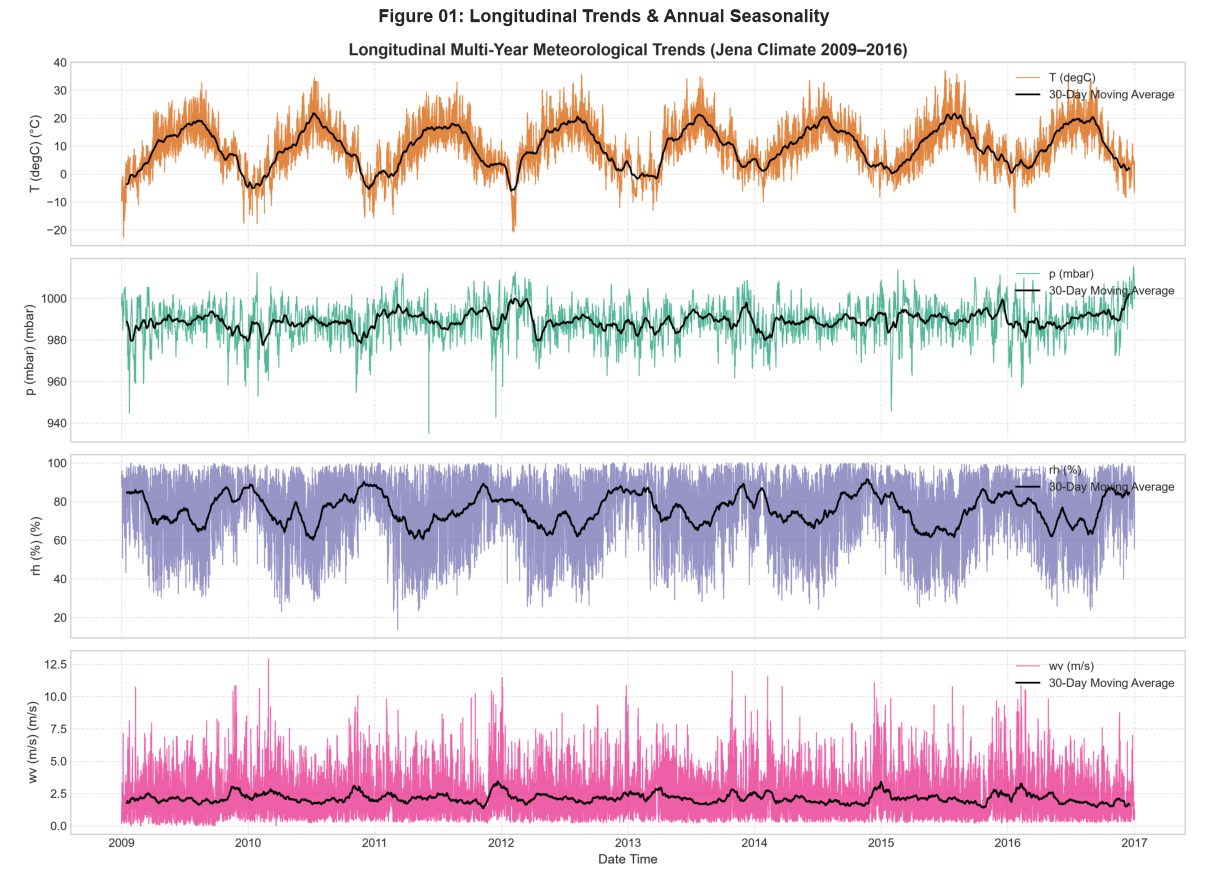

In [8]:
img = mpimg.imread(str(FIGURES_DIR / "01_yearly_trends_seasonality.png"))
plt.figure(figsize=(16, 9)); plt.imshow(img); plt.axis("off")
plt.title("Figure 01: Longitudinal Trends & Annual Seasonality", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 4.2 Visual 2 — Correlation Heatmap

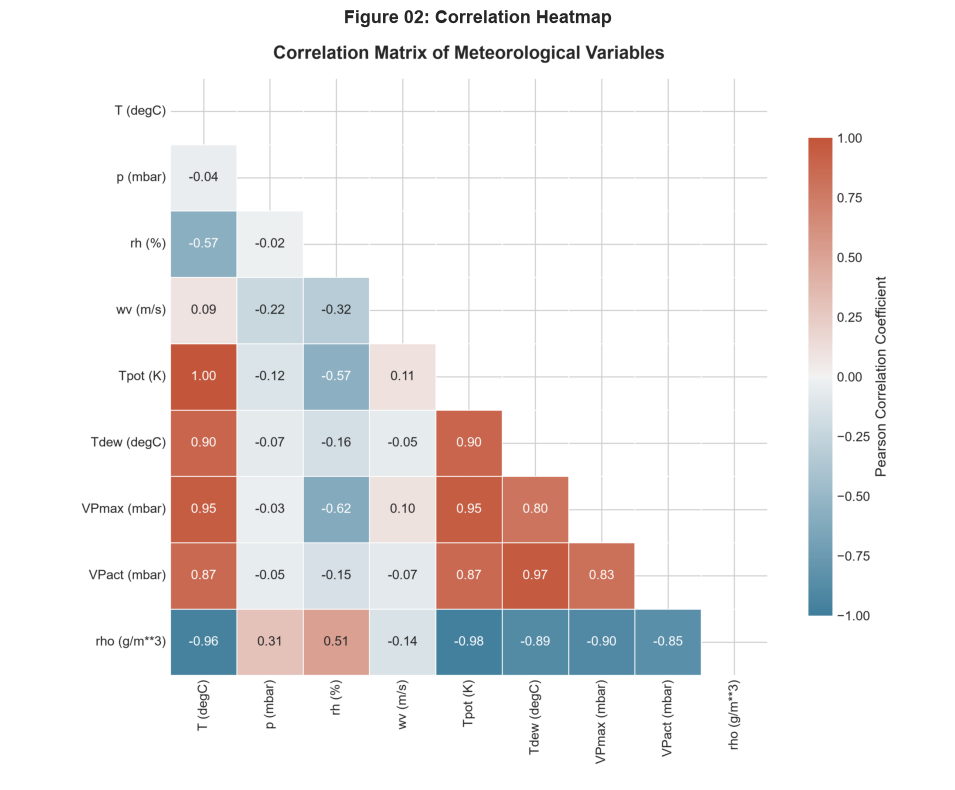

In [9]:
img = mpimg.imread(str(FIGURES_DIR / "02_correlation_heatmap.png"))
plt.figure(figsize=(10, 8)); plt.imshow(img); plt.axis("off")
plt.title("Figure 02: Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 4.3 Visual 3 — Diurnal Patterns

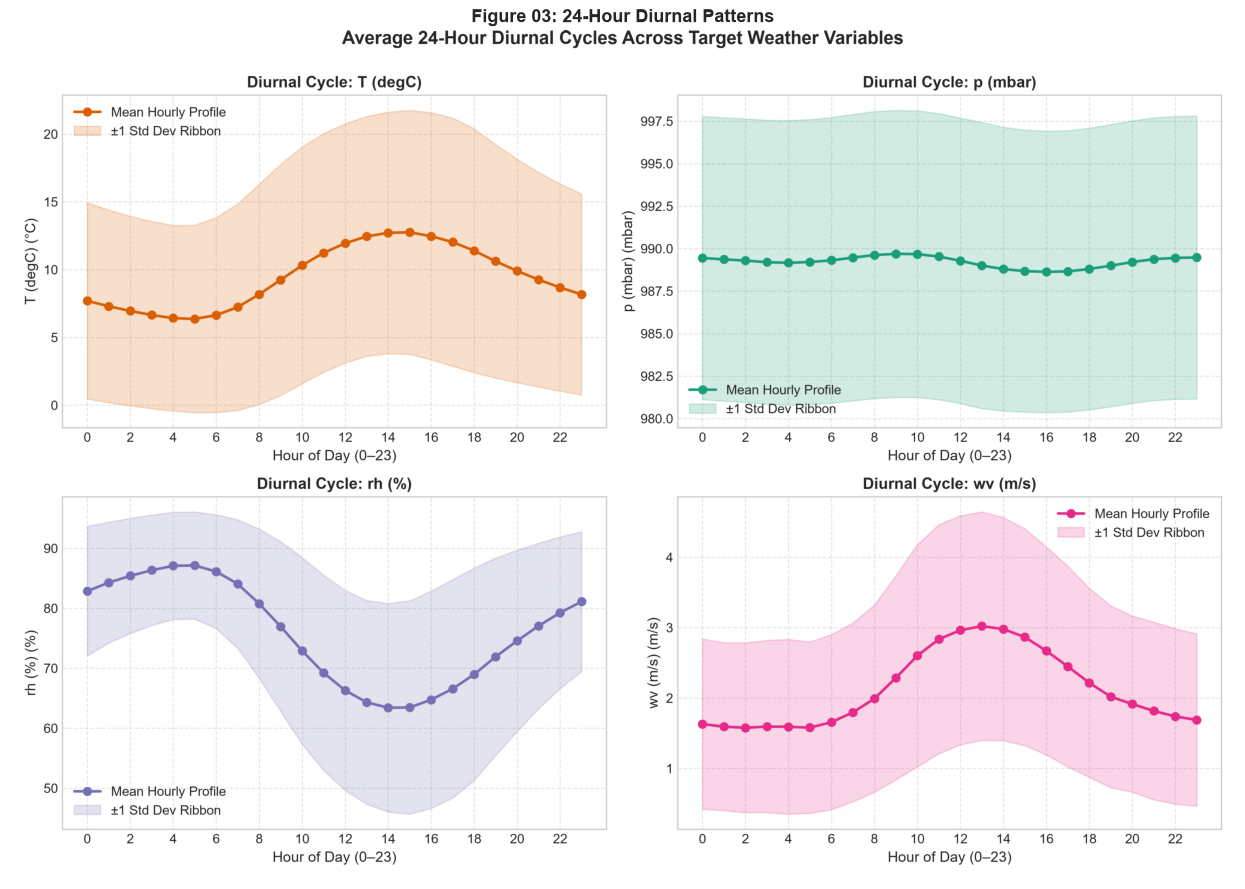

In [10]:
img = mpimg.imread(str(FIGURES_DIR / "03_diurnal_hourly_patterns.png"))
plt.figure(figsize=(13, 9)); plt.imshow(img); plt.axis("off")
plt.title("Figure 03: 24-Hour Diurnal Patterns", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 4.4 Visual 4 — Temperature vs. Humidity by Season

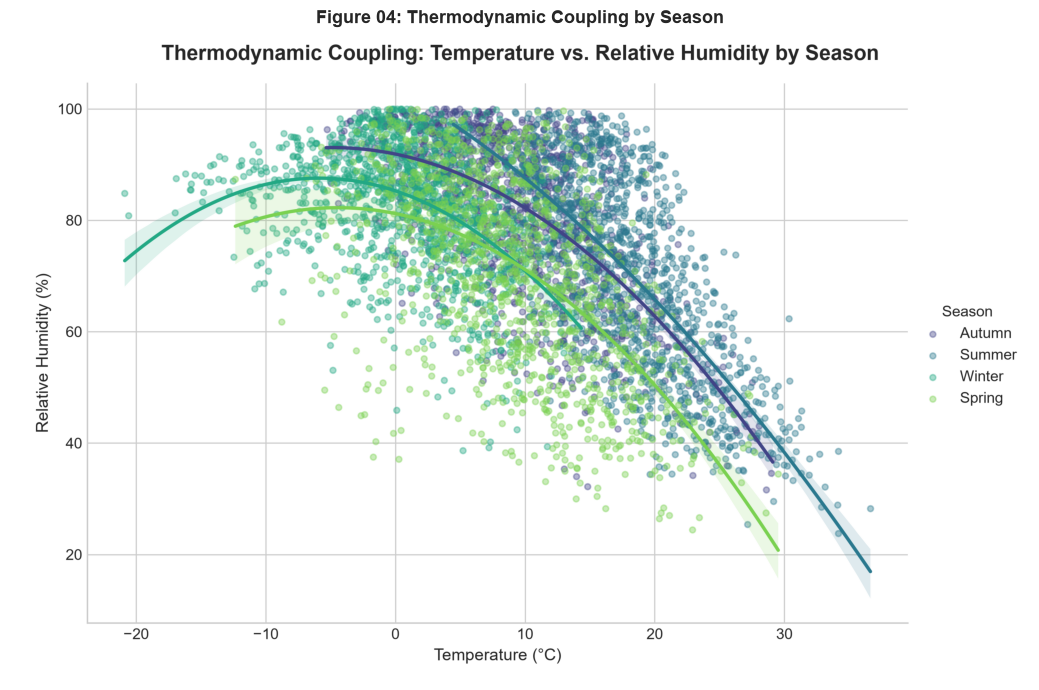

In [11]:
img = mpimg.imread(str(FIGURES_DIR / "04_temp_humidity_pressure_coupling.png"))
plt.figure(figsize=(12, 7)); plt.imshow(img); plt.axis("off")
plt.title("Figure 04: Thermodynamic Coupling by Season", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 4.5 Visual 5 — Seasonal Distributions & Extremes

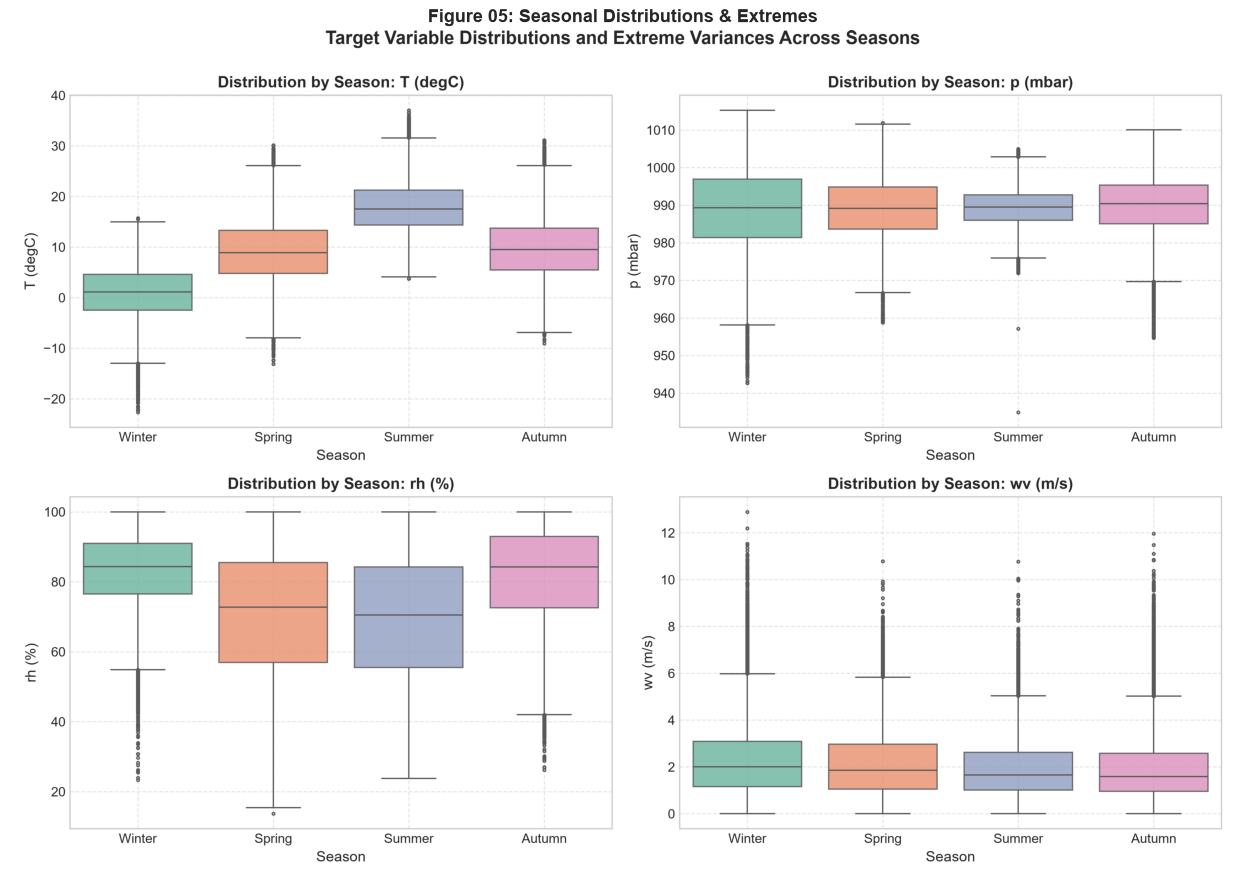

In [12]:
img = mpimg.imread(str(FIGURES_DIR / "05_distributions_and_outliers.png"))
plt.figure(figsize=(13, 9)); plt.imshow(img); plt.axis("off")
plt.title("Figure 05: Seasonal Distributions & Extremes", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Key EDA Takeaways

| Observation | Implication for Modelling |
|---|---|
| Strong annual sinusoidal pattern in temperature (±20 °C amplitude) | Cyclical Year_sin/cos features are essential |
| Temperature and relative humidity negatively correlated (r ≈ −0.57) | Joint multivariate modelling captures this coupling |
| 24-hour diurnal peak in temperature (afternoon) and trough in humidity | Day_sin/cos features encode this |
| Wind velocity is highly skewed and turbulent | RMSE will be highest for `wv`; needs careful evaluation |
| No missing values after cleaning; strict monotonic hourly index | Pipeline is leakage-safe and reproducible |

**→ Proceed to Notebook 02: Feature Engineering & Sequence Formulation**
